Why a tool is required?


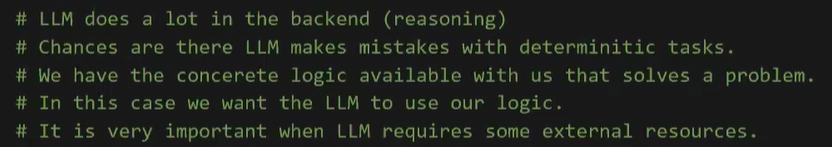

In [1]:
# A tool is a JSON schema.
# A tool schema contains the details (description) of a function (user defined).

## Flow

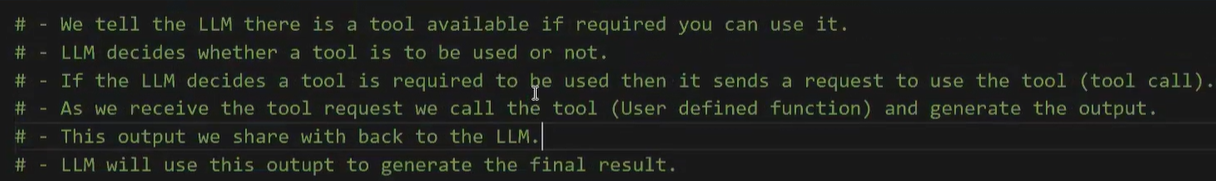

### Steps

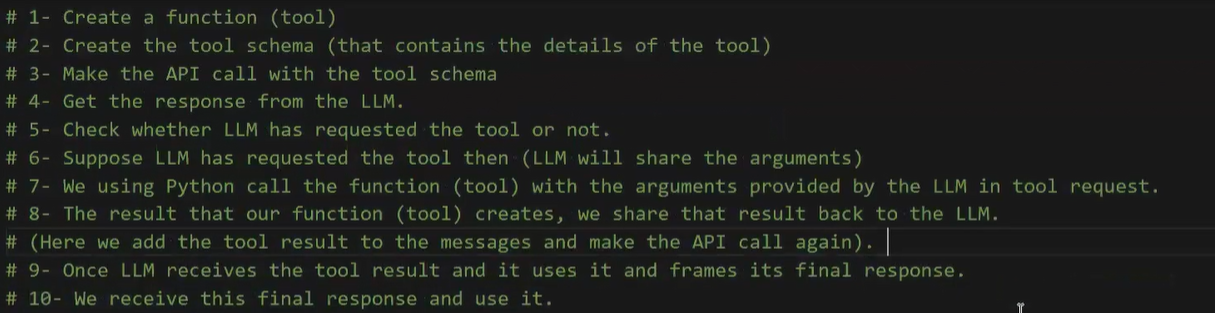

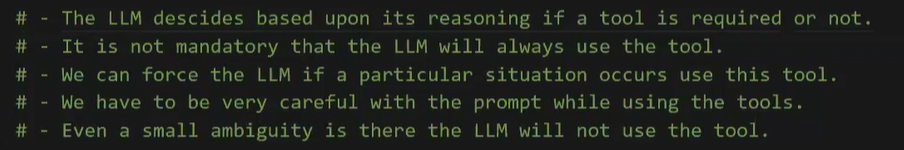

## Example 1

In [2]:
# Add two numbers
# Calculate total experience from a resume

### Step 1: Create a tool (function)

In [3]:
def add(a,b):
    return a + b

### Step 2: Create the tool schema

In [4]:
add_tool_schema = {
    "type": "function",
    "function": {
        "name": "add",
        "description": "Takes two numeric values and returns their sum.", 
        "parameters": {
            "type": "object", 
            "properties": {
                "a": {"type": "number", "description": "A numeric value int or float"},
                "b": {"type": "number", "description": "A numeric value int or float"},
            },
            "required": ["a", "b"]
        }
    }
}

add_tool_schema

{'type': 'function',
 'function': {'name': 'add',
  'description': 'Takes two numeric values and returns their sum.',
  'parameters': {'type': 'object',
   'properties': {'a': {'type': 'number',
     'description': 'A numeric value int or float'},
    'b': {'type': 'number', 'description': 'A numeric value int or float'}},
   'required': ['a', 'b']}}}

In [5]:
tools = [add_tool_schema]

### Step 3: Make API call

In [1]:
import os
import json
from openai import OpenAI

In [2]:
client = OpenAI(api_key=os.getenv("OPENAI_SECRET_KEY"))

In [ ]:
def make_apicall_with_tool(prompt, tools):
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{'role': 'user', 'content': prompt}],
        tools=tools
    )

    return response

In [28]:
prompt = 'Sum 5 and 10'

### Step 4: Get the response from LLM

In [29]:
result = make_apicall_with_tool(prompt=prompt, tools=tools)
result

ChatCompletion(id='chatcmpl-D5T0QKUolbE65HytjJ3JtlqA1XcdG', choices=[Choice(finish_reason='tool_calls', index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_x5EIIjp5HouQX3CFvphezjKt', function=Function(arguments='{"a":5,"b":10}', name='add'), type='function')]))], created=1770195510, model='gpt-4o-mini-2024-07-18', object='chat.completion', service_tier='default', system_fingerprint='fp_1590f93f9d', usage=CompletionUsage(completion_tokens=17, prompt_tokens=70, total_tokens=87, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))

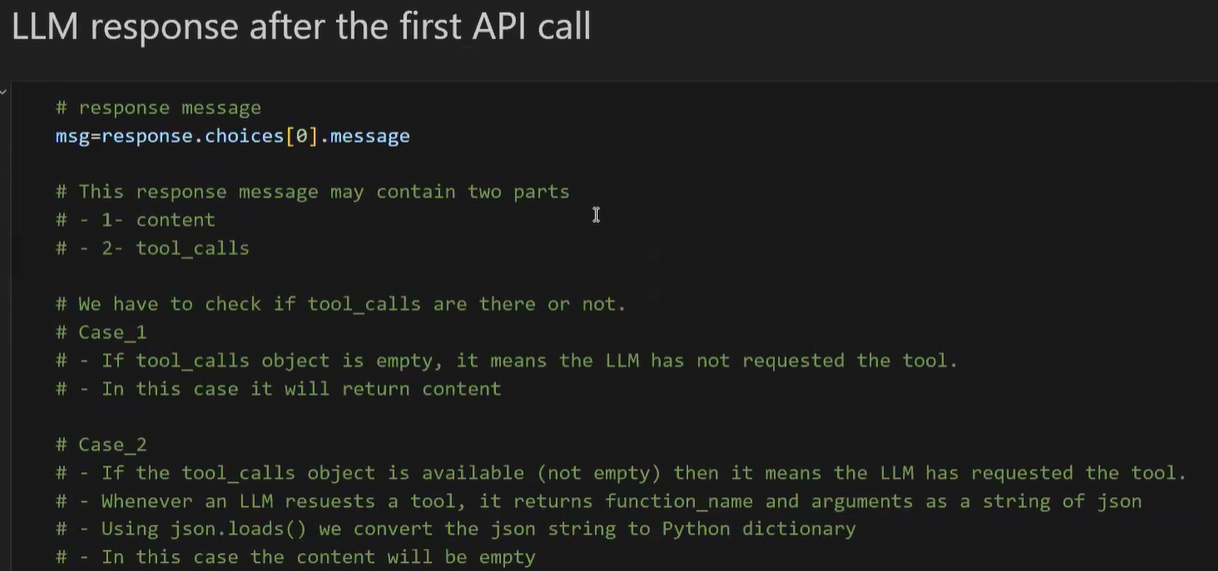

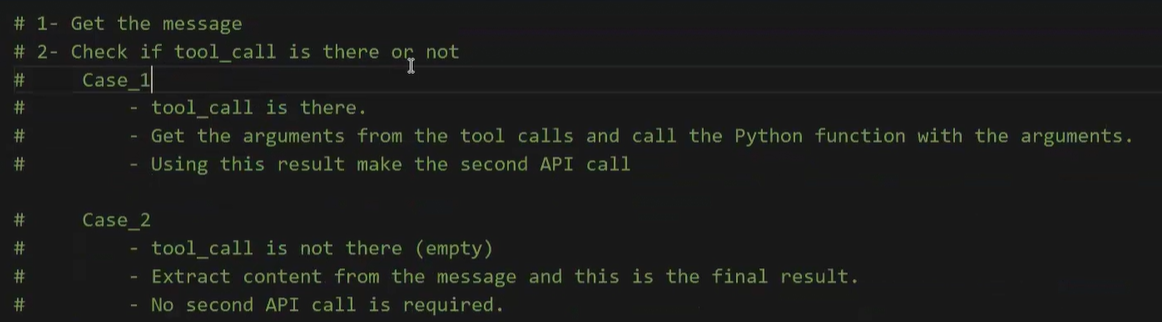

### Step 5: Checking the tool request (whether LLM has requested the tool or not)

In [36]:
msg = result.choices[0].message
msg

ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_x5EIIjp5HouQX3CFvphezjKt', function=Function(arguments='{"a":5,"b":10}', name='add'), type='function')])

### Step 6: Fetching the arguments from tool_calls

In [37]:
args = result.choices[0].message.tool_calls[0].function.arguments
## this will fail if there is no tool call.

if msg.tool_calls:
    tool_call = msg.tool_calls[0]
    args = json.loads(tool_call.function.arguments)
else:
    args = msg.content

In [42]:
tool_call.function

Function(arguments='{"a":5,"b":10}', name='add')

In [39]:
if args:
    print("tool is requested", args)
else:
    print("tool is not requested")

tool is requested {'a': 5, 'b': 10}


### Step 7: Calling the function using the args provided by LLM

In [41]:
result = add(**args)
result

15

### Step 8: Send the result back to the LLM

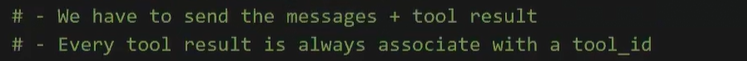

In [45]:
tool_call.id

'call_x5EIIjp5HouQX3CFvphezjKt'

In [50]:
messages = [{'role': 'user', 'content': prompt}] + [msg, {"role": "tool", "tool_call_id": tool_call.id, "content": str(result)}]
messages

[{'role': 'user', 'content': 'Sum 5 and 10'},
 ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_x5EIIjp5HouQX3CFvphezjKt', function=Function(arguments='{"a":5,"b":10}', name='add'), type='function')]),
 {'role': 'tool',
  'tool_call_id': 'call_x5EIIjp5HouQX3CFvphezjKt',
  'content': '15'}]

### Step 9: Second API call to get the final response

In [51]:
resp = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=messages,
    tools=tools
)

In [52]:
resp

ChatCompletion(id='chatcmpl-D5YoNAYwspYZGxlhFZzxXpRCbkYH7', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='The sum of 5 and 10 is 15.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1770217827, model='gpt-4o-mini-2024-07-18', object='chat.completion', service_tier='default', system_fingerprint='fp_1590f93f9d', usage=CompletionUsage(completion_tokens=13, prompt_tokens=95, total_tokens=108, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))

### Step 10: Final Content

In [53]:
resp.choices[0].message.content

'The sum of 5 and 10 is 15.'

In [54]:
resp.choices[0].message.tool_calls

### What is the need for the second API call?

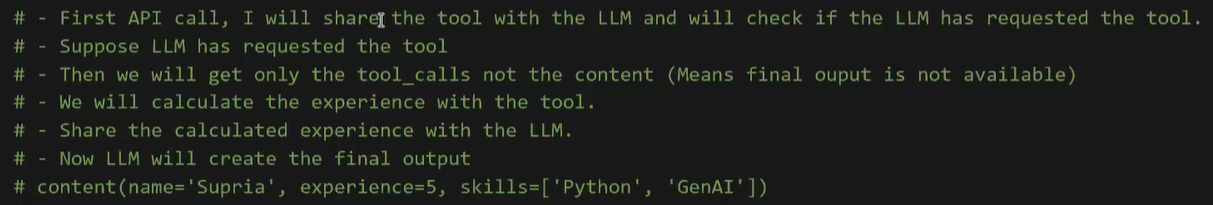

## Example 2

Get the salary of an employee

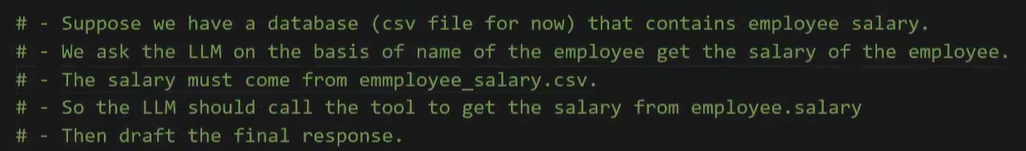

In [3]:
import pandas as pd

In [13]:
df = pd.DataFrame({"name": ["vedu", "satya", "maha", "yogna", "yash"],
                  "salary": [1116000, 2050000, 1300075, 3004082, 205067]})
df

,name,salary
0,vedu,1116000
1,satya,2050000
2,maha,1300075
3,yogna,3004082
4,yash,205067


In [14]:
df.to_csv('salary.csv', index=False)

### Step 1: Create the tool

In [34]:
def get_salary(name):
    try:
        df = pd.read_csv('salary.csv')

        return df[df.name.isin([name.lower()])]['salary'].iloc[0]
    except Exception as e:
        print("Data not found.", e)

In [35]:
df.name.isin(['yash'])

0    False
1    False
2    False
3    False
4     True
Name: name, dtype: bool

In [36]:
get_salary('maha')

np.int64(1300075)

### Step 2: Create the tool schema

In [37]:
salary_tool = {
    "type": "function",
    "function": {
        "name": "get_salary",
        "description": "Get the salary based upon the given name",
        "parameters": {
            "type": "object",
            "properties": {
                "name": {"type": "string", "description": "name of the person who we need to get the salary of."}
            },
            "required": ["name"]
        }
    }
}

salary_tool

{'type': 'function',
 'function': {'name': 'get_salary',
  'description': 'Get the salary based upon the given name',
  'parameters': {'type': 'object',
   'properties': {'name': {'type': 'string',
     'description': 'name of the person who we need to get the salary of.'}},
   'required': ['name']}}}

In [38]:
tools = [salary_tool]

### Step 3: Create Prompts

In [39]:
system_prompt = '''You are a salary reviewer baased upon the designation and role of an employee.
Your task is to get the salary of an employee by using the given tool always and then give your review on the salary whether it is 'High', 'Medium' or 'Low' based upon the designation and role.'''

user_query = '''Hi, I am yash working as a Senior Python Developer for the past 6 years.'''

### Step 4: Make API Call

In [50]:
def make_api_call_with_tool(client, tools, messages):
    
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=messages,
        tools=tools
    )

    return response

In [84]:
messages=[{'role': 'system', 'content': system_prompt},
                  {'role': 'user', 'content': user_query}]

In [ ]:
result = make_api_call_with_tool(client, tools, messages)

In [69]:
messages

[{'role': 'system',
  'content': "You are a salary reviewer baased upon the designation and role of an employee.\nYour task is to get the salary of an employee by using the given tool always and then give your review on the salary whether it is 'High', 'Medium' or 'Low' based upon the designation and role."},
 {'role': 'user',
  'content': 'Hi, I am yash working as a Senior Python Developer for the past 6 years.'}]

In [42]:
result

ChatCompletion(id='chatcmpl-D67sMw1cZAiKYiXqYyBnyP9AN2IRy', choices=[Choice(finish_reason='tool_calls', index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_TammlVLGRVyhsjv6dfr7CuHS', function=Function(arguments='{"name":"Yash"}', name='get_salary'), type='function')]))], created=1770352614, model='gpt-4o-mini-2024-07-18', object='chat.completion', service_tier='default', system_fingerprint='fp_6c0d1490cb', usage=CompletionUsage(completion_tokens=15, prompt_tokens=138, total_tokens=153, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))

### Step 5: Checking the tool request

In [43]:
ai_message = result.choices[0].message

if ai_message.tool_calls:
    print("tool request is made")
    tool_call = ai_message.tool_calls[0]
    tool_name = tool_call.function.name
    args = json.loads(tool_call.function.arguments)
else:
    print("no tool request is made")
    ai_message = ai_message.content
    args = None

tool request is made


In [44]:
tool_call, tool_name, args

(ChatCompletionMessageFunctionToolCall(id='call_TammlVLGRVyhsjv6dfr7CuHS', function=Function(arguments='{"name":"Yash"}', name='get_salary'), type='function'),
 'get_salary',
 {'name': 'Yash'})

### Step 6: Get the Salary using the tool

In [75]:
salary = get_salary(**args)
salary =  int(salary)
salary

205067

In [54]:
ai_message

ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_TammlVLGRVyhsjv6dfr7CuHS', function=Function(arguments='{"name":"Yash"}', name='get_salary'), type='function')])

### Step 7: Second API Call

In [85]:
messages = messages + [ai_message] + [{'role': 'tool', 'content': str(salary), 'tool_call_id': tool_call.id}]
messages

[{'role': 'system',
  'content': "You are a salary reviewer baased upon the designation and role of an employee.\nYour task is to get the salary of an employee by using the given tool always and then give your review on the salary whether it is 'High', 'Medium' or 'Low' based upon the designation and role."},
 {'role': 'user',
  'content': 'Hi, I am yash working as a Senior Python Developer for the past 6 years.'},
 ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_TammlVLGRVyhsjv6dfr7CuHS', function=Function(arguments='{"name":"Yash"}', name='get_salary'), type='function')]),
 {'role': 'tool',
  'content': '205067',
  'tool_call_id': 'call_TammlVLGRVyhsjv6dfr7CuHS'}]

In [86]:
result2 = make_api_call_with_tool(client, tools, messages)

In [90]:
print(result2.choices[0].message.content)

The salary for Yash, who is a Senior Python Developer with 6 years of experience, is $205,067. 

### Salary Review:
This salary can be considered **Medium** for a Senior Python Developer in most markets, depending on the cost of living and demand for Python skills in your area. It is a competitive salary that recognizes your experience, but it may be on the lower end for some high-demand regions or companies.


## Create a pipeline with a single tool

In [135]:
def llm_call_with_tools(client, messages, tools):
    try:
        while True:
            response = client.chat.completions.create(
                model='gpt-4o-mini',
                messages=messages,
                tools=tools
            )

            ai_message = response.choices[0].message
            print(ai_message)

            if not ai_message.tool_calls:
                result = ai_message.content
                return result # breaks the loop
            
            tool_call = ai_message.tool_calls[0]
            args = json.loads(tool_call.function.arguments)
            salary = get_salary(**args)

            if salary != None:
                salary = int(salary)

            messages = messages + [ai_message] + [{'role': 'tool', 'content': str(salary), 'tool_call_id': tool_call.id}]  
    except Exception as e:
        print("failed to review your details", e)  

In [140]:
system_prompt = '''You are a salary reviewer baased upon the designation and role of an employee.
Your task is to get the salary of an employee by using the given tool always and then give your review on the salary whether it is 'High', 'Medium' or 'Low' based upon the designation and role.'''

user_query = '''Hi, I am yash working as a full-stack Developer for the past 6 years.'''

messages=[{'role': 'system', 'content': system_prompt},
                  {'role': 'user', 'content': user_query}]

In [141]:
res = llm_call_with_tools(client=client, messages=messages, tools=tools)

ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_59BCxzc30PyPa9tifncOTKyr', function=Function(arguments='{"name":"yash"}', name='get_salary'), type='function')])
ChatCompletionMessage(content="Yash, as a full-stack developer with 6 years of experience, your salary of $205,067 is considered 'High'. This level of compensation reflects your experience and skill set in the field.", refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None)


In [142]:
print(res)

Yash, as a full-stack developer with 6 years of experience, your salary of $205,067 is considered 'High'. This level of compensation reflects your experience and skill set in the field.


## Multiple Tools

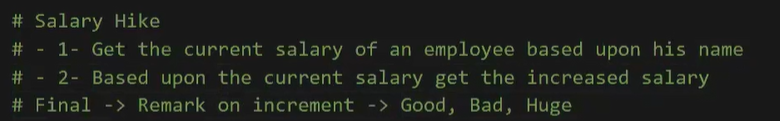

In [191]:
def get_current_salary(emp_name):
    if emp_name not in df.name.values:
        return 'No information available for this employee in the database.'
    return df[df.name.isin([emp_name])]['salary'].iloc[0].item()

In [154]:
def get_increased_salary(salary):
    return salary * 1.25

In [155]:
current_salary_tool_schema = {
    "type": "function",
    "function": {
        "name": "get_current_salary",
        "description": "Get the current salary of an employee based upon the name from the database.",
        "parameters": {
            "type": "object",
            "properties": {
                "emp_name": {"type": "string", "description": "The name of the employee who we need to get the current salary of."}
            },
            "required": ["emp_name"]
        }
    }
}

current_salary_tool_schema

{'type': 'function',
 'function': {'name': 'get_current_salary',
  'description': 'Get the current salary of an employee based upon the name from the database.',
  'parameters': {'type': 'object',
   'properties': {'emp_name': {'type': 'string',
     'description': 'The name of the employee who we need to get the current salary of.'}},
   'required': ['emp_name']}}}

In [156]:
increased_salary_tool_schema = {
    "type": "function",
    "function": {
        "name": "get_increased_salary",
        "description": "Get the increased salary of an employee based upon the current salary from the database.",
        "parameters": {
            "type": "object",
            "properties": {
                "salary": {"type": "number", "description": "The current salary of an employee."}
            },
            "required": ["salary"]
        }
    }
}

increased_salary_tool_schema

{'type': 'function',
 'function': {'name': 'get_increased_salary',
  'description': 'Get the increased salary of an employee based upon the current salary from the database.',
  'parameters': {'type': 'object',
   'properties': {'salary': {'type': 'number',
     'description': 'The current salary of an employee.'}},
   'required': ['salary']}}}

In [160]:
tools = [current_salary_tool_schema, increased_salary_tool_schema]

tools

[{'type': 'function',
  'function': {'name': 'get_current_salary',
   'description': 'Get the current salary of an employee based upon the name from the database.',
   'parameters': {'type': 'object',
    'properties': {'emp_name': {'type': 'string',
      'description': 'The name of the employee who we need to get the current salary of.'}},
    'required': ['emp_name']}}},
 {'type': 'function',
  'function': {'name': 'get_increased_salary',
   'description': 'Get the increased salary of an employee based upon the current salary from the database.',
   'parameters': {'type': 'object',
    'properties': {'salary': {'type': 'number',
      'description': 'The current salary of an employee.'}},
    'required': ['salary']}}}]

In [199]:
system_prompt = '''You are a salary reviewer based upon the current and increased salary of an employee.
Always use the tools to fetch the current salary and the increased salary.
Never use your internal knowledge to assume the current or increased salary or ask them from the employee.
Once you get the current salary and the increased salary, then give your review on the salary increment whether it is 'Good', 'Bad' or 'Excellent' based upon the designation and role.'''

user_query = '''Hi, My name is yash and I am working as a full-stack Developer for the past 6 years.'''

messages=[{'role': 'system', 'content': system_prompt},
                  {'role': 'user', 'content': user_query}]

### First API Call

In [169]:
response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=messages,
    tools=tools
)

In [194]:
ai_message = response.choices[0].message

In [195]:
tool_calls = ai_message.tool_calls
tool_calls

[ChatCompletionMessageFunctionToolCall(id='call_PPHpnIJ8m1ApP5MVnpuI0LYd', function=Function(arguments='{"emp_name":"yash"}', name='get_current_salary'), type='function')]

In [174]:
len(tool_calls)

1

In [176]:
tool_call = tool_calls[0]
tool_call.function

Function(arguments='{"emp_name":"yash"}', name='get_current_salary')

In [201]:
args = json.loads(tool_call.function.arguments)
current_salary = get_current_salary(**args)
current_salary

205067

In [202]:
messages = messages + [ai_message, {'role': 'tool', 'content': str(current_salary), 'tool_call_id': tool_call.id}]
messages

[{'role': 'system',
  'content': "You are a salary reviewer based upon the current and increased salary of an employee.\nAlways use the tools to fetch the current salary and the increased salary.\nNever use your internal knowledge to assume the current or increased salary or ask them from the employee.\nOnce you get the current salary and the increased salary, then give your review on the salary increment whether it is 'Good', 'Bad' or 'Excellent' based upon the designation and role."},
 {'role': 'user',
  'content': 'Hi, My name is yash and I am working as a full-stack Developer for the past 6 years.'},
 ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_PPHpnIJ8m1ApP5MVnpuI0LYd', function=Function(arguments='{"emp_name":"yash"}', name='get_current_salary'), type='function')]),
 {'role': 'tool',
  'content': '205067',
  'tool_call_id': 'call_PPHpnIJ8m1ApP5MVnpuI0

### Second API Call

In [204]:
response2 = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=messages,
    tools=tools
)

In [209]:
sec_ai_msg = response2.choices[0].message
sec_ai_msg

ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_sC2xiYhyMCng2FBUSzbVe5Pg', function=Function(arguments='{"salary":205067}', name='get_increased_salary'), type='function')])

In [210]:
sec_tool_call = sec_ai_msg.tool_calls[0]
sec_tool_call

ChatCompletionMessageFunctionToolCall(id='call_sC2xiYhyMCng2FBUSzbVe5Pg', function=Function(arguments='{"salary":205067}', name='get_increased_salary'), type='function')

In [212]:
sec_args = json.loads(sec_tool_call.function.arguments)
sec_args

{'salary': 205067}

In [213]:
increased_sal = get_increased_salary(**sec_args)
increased_sal

256333.75

### Third API Call

In [214]:
messages = messages + [sec_ai_msg, {'role': 'tool', 'content': str(increased_sal), 'tool_call_id': sec_tool_call.id}]
messages

[{'role': 'system',
  'content': "You are a salary reviewer based upon the current and increased salary of an employee.\nAlways use the tools to fetch the current salary and the increased salary.\nNever use your internal knowledge to assume the current or increased salary or ask them from the employee.\nOnce you get the current salary and the increased salary, then give your review on the salary increment whether it is 'Good', 'Bad' or 'Excellent' based upon the designation and role."},
 {'role': 'user',
  'content': 'Hi, My name is yash and I am working as a full-stack Developer for the past 6 years.'},
 ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_PPHpnIJ8m1ApP5MVnpuI0LYd', function=Function(arguments='{"emp_name":"yash"}', name='get_current_salary'), type='function')]),
 {'role': 'tool',
  'content': '205067',
  'tool_call_id': 'call_PPHpnIJ8m1ApP5MVnpuI0

In [215]:
response3 = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=messages,
    tools=tools
)

In [219]:
print(response3.choices[0].message.content)

Yash, your current salary is $205,067, and your increased salary is $256,333.75. 

Considering your role as a full-stack developer with 6 years of experience, the increment is quite substantial. Therefore, I would classify this salary increment as **Excellent**.


### Possible scenarios with multiple tools

In [220]:
# 1) Sequential tool calls
# 2) Parallel tool calls
# 3) No tool calls